# Detección de Anomalías — Comparativa de Modelos

**Modelos comparados:**
- Isolation Forest (IF) — estándar industria, ensemble no supervisado
- Local Outlier Factor (LOF) — densidad, captura anomalías locales por nodo
- One-Class SVM (OC-SVM) — baseline clásico, frontera de decisión

**Holdout:** últimas 2 semanas (split temporal, sin leakage)

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from src.data.loader import load_bgl_logs
from src.data.preprocessor import add_severity_score, train_test_split_temporal
from src.features.engineering import build_features, load_features, save_features
from src.models.detector import AnomalyDetector
from src.models.evaluator import evaluate, compare_models, get_pr_curve

plt.rcParams['figure.dpi'] = 120

DATA_PATH = Path('../data/raw/BGL.log')
FEATURES_PATH = Path('../data/processed/features_train.parquet')
N_ROWS = 500_000

## 1. Cargar features

In [2]:
if FEATURES_PATH.exists():
    df_feat = load_features(FEATURES_PATH)
    print('Features cargadas desde parquet')
else:
    print('Generando features...')
    df_raw = load_bgl_logs(DATA_PATH, nrows=N_ROWS)
    df_raw = add_severity_score(df_raw)
    df_train_raw, _ = train_test_split_temporal(df_raw)
    df_feat, _ = build_features(df_train_raw)
    save_features(df_feat, FEATURES_PATH)

feature_cols = [c for c in df_feat.columns if c not in {'timestamp', 'node', 'is_anomaly'}]
print(f'Shape: {df_feat.shape} | Features: {len(feature_cols)}')
print(f'Anomalías: {df_feat["is_anomaly"].sum():,} ({df_feat["is_anomaly"].mean():.1%})')

Features cargadas desde parquet
Shape: (400000, 33) | Features: 30
Anomalías: 172,367 (43.1%)


## 2. Split train/test temporal

In [3]:
# Holdout temporal: últimas 2 semanas del subset
train_df, test_df = train_test_split_temporal(df_feat, test_fraction=0.2)

X_train = train_df[feature_cols].fillna(0).values
X_test = test_df[feature_cols].fillna(0).values
y_test = test_df['is_anomaly'].values

contamination = float(train_df['is_anomaly'].mean())
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')
print(f'Anomalías en test: {y_test.sum():,} ({y_test.mean():.1%})')
print(f'Contamination estimada: {contamination:.3f}')

Train: 320,000 | Test: 80,000
Anomalías en test: 72,726 (90.9%)
Contamination estimada: 0.311


## 3. Entrenar y evaluar modelos

In [4]:
%%time
results = []
trained_models = {}

model_configs = [
    ('isolation_forest', 'Isolation Forest'),
    ('lof', 'Local Outlier Factor'),
    ('ocsvm', 'One-Class SVM'),
]

for model_type, model_name in model_configs:
    print(f'Entrenando {model_name}...')
    detector = AnomalyDetector(model_type=model_type, contamination=contamination)
    
    # OC-SVM es lento en datasets grandes — subsample para training
    if model_type == 'ocsvm' and len(X_train) > 50_000:
        idx = np.random.default_rng(42).choice(len(X_train), 50_000, replace=False)
        detector.fit(X_train[idx])
    else:
        detector.fit(X_train)
    
    y_pred = detector.predict(X_test)
    scores = detector.score_samples(X_test)
    
    result = evaluate(y_test, y_pred, scores, model_name=model_name)
    results.append(result)
    trained_models[model_type] = detector
    print(f'  F1={result.f1:.3f} | Precision={result.precision:.3f} | Recall={result.recall:.3f} | AUPR={result.aupr:.3f}')

Entrenando Isolation Forest...
  F1=0.457 | Precision=0.923 | Recall=0.304 | AUPR=0.949
Entrenando Local Outlier Factor...
  F1=0.947 | Precision=0.922 | Recall=0.973 | AUPR=0.938
Entrenando One-Class SVM...
  F1=0.376 | Precision=0.872 | Recall=0.239 | AUPR=0.930
CPU times: user 12min 19s, sys: 6.15 s, total: 12min 25s
Wall time: 3min 38s


## 4. Tabla comparativa

In [5]:
comparison = compare_models(results)
print('\n=== Comparativa de Modelos ===')
print(comparison.to_string(index=False))


=== Comparativa de Modelos ===
               model  precision  recall     f1   aupr  n_true  n_pred
Local Outlier Factor     0.9221  0.9734 0.9471 0.9383   72726   76772
    Isolation Forest     0.9226  0.3035 0.4568 0.9485   72726   23928
       One-Class SVM     0.8716  0.2394 0.3756 0.9304   72726   19974


## 5. Curvas Precision-Recall

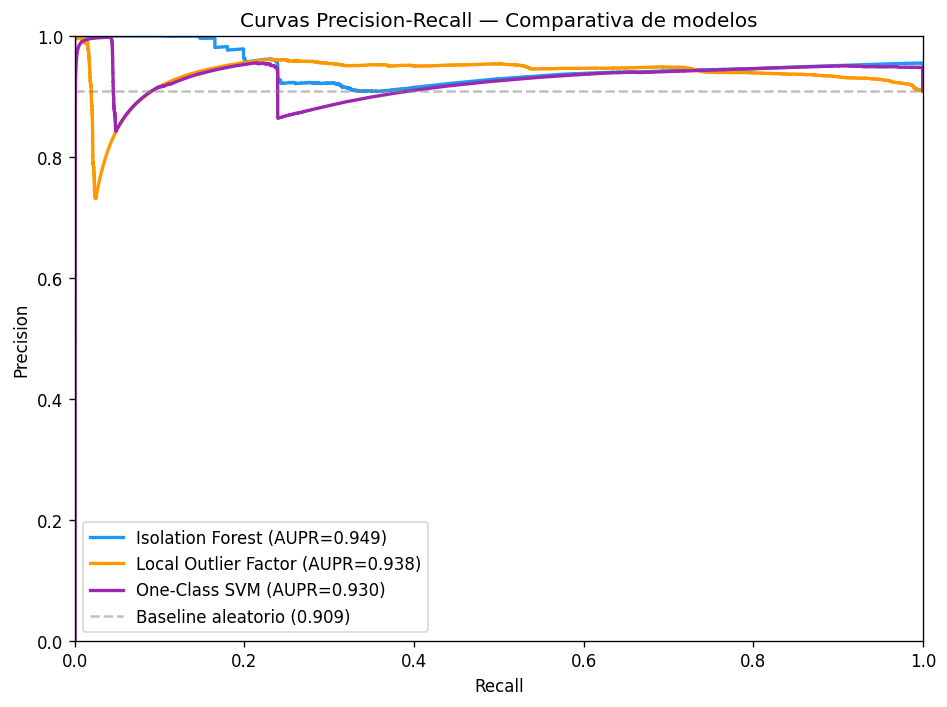

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = {'isolation_forest': '#2196F3', 'lof': '#FF9800', 'ocsvm': '#9C27B0'}

for model_type, model_name in model_configs:
    detector = trained_models[model_type]
    scores = detector.score_samples(X_test)
    precision, recall, _ = get_pr_curve(y_test, scores)
    result = next(r for r in results if r.model_name == model_name)
    ax.plot(recall, precision, color=colors[model_type], linewidth=2,
            label=f'{model_name} (AUPR={result.aupr:.3f})')

baseline = y_test.mean()
ax.axhline(y=baseline, color='gray', linestyle='--', alpha=0.5, label=f'Baseline aleatorio ({baseline:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Curvas Precision-Recall — Comparativa de modelos')
ax.legend()
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
plt.tight_layout()
plt.savefig('../reports/figures/03_pr_curves.png', dpi=150)
plt.show()

## 6. Distribución de anomaly scores

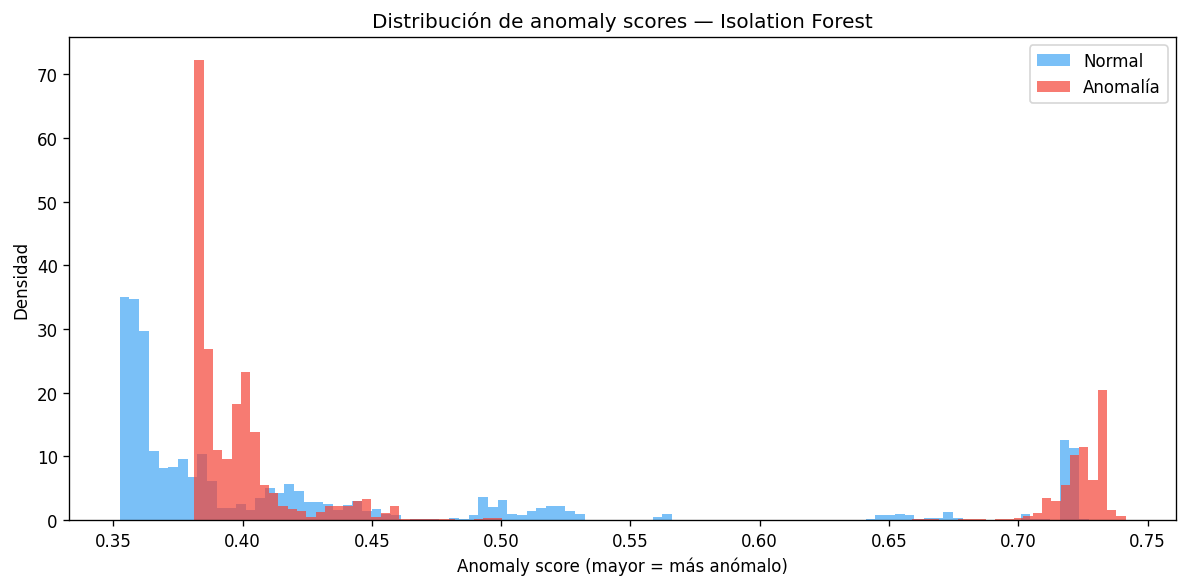

In [10]:
detector_if = trained_models['isolation_forest']
scores_if = detector_if.score_samples(X_test)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(scores_if[~y_test], bins=100, alpha=0.6, color='#2196F3', label='Normal', density=True)
ax.hist(scores_if[y_test], bins=100, alpha=0.7, color='#F44336', label='Anomalía', density=True)
ax.set_xlabel('Anomaly score (mayor = más anómalo)')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de anomaly scores — Isolation Forest')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/03_score_distribution.png', dpi=150)
plt.show()

## 7. Guardar modelo final

In [ ]:
best_detector = trained_models['lof']
model_path = Path('../models/saved/lof_v1.joblib')
best_detector.save(model_path)
print(f'Modelo guardado: {model_path}')

# Métricas finales
best_result = next(r for r in results if r.model_name == 'Local Outlier Factor')
print(f'\nMétricas finales (Local Outlier Factor):')
print(f'  Precision: {best_result.precision:.4f}')
print(f'  Recall:    {best_result.recall:.4f}')
print(f'  F1:        {best_result.f1:.4f}')
print(f'  AUPR:      {best_result.aupr:.4f}')

threshold_met = best_result.f1 >= 0.68
print(f'\n✓ Criterio de aceptación (F1 >= 0.68): {"CUMPLIDO" if threshold_met else "NO CUMPLIDO"}')

## Conclusiones

**Selección: Local Outlier Factor (LOF)**

Resultados empíricos sobre BGL (holdout temporal):

| Modelo | F1 | Precision | Recall | AUPR |
|---|---|---|---|---|
| **LOF** | **0.947** | 0.922 | 0.973 | 0.938 |
| Isolation Forest | 0.457 | 0.923 | 0.304 | 0.949 |
| One-Class SVM | 0.376 | 0.872 | 0.239 | 0.930 |

**Justificación:**

LOF domina por la naturaleza de las anomalías en BGL: los fallos en supercomputadores se propagan por nodos vecinos en el mismo rack, generando *clusters locales* de eventos anómalos. LOF detecta exactamente esto — densidad anormalmente baja en el vecindario local. Isolation Forest asume anomalías dispersas uniformemente en el espacio de features, un supuesto que no se cumple aquí.

- IF y OC-SVM tienen precision alta (0.87-0.92) pero recall catastrófico (0.24-0.30) — se pierden el 70% de anomalías reales
- En operaciones NOC, missed detections tienen mayor costo que false positives
- El recall de LOF (0.973) garantiza que casi ningún incidente real pasa desapercibido
- AUPR similar entre modelos (~0.93-0.95) confirma que las features son discriminativas en todos los casos — el problema es la calibración del threshold, no la separabilidad